In [1]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns


from matplotlib import style
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

import dask
import dask.dataframe as dd
from dask.distributed import Client


In [2]:
DATA_FOLDER = "../data"
COLORADO_DATA_FOLDER = os.path.join(DATA_FOLDER,"Colorado_Data")
COLORADO_DF_PATH = os.path.join(DATA_FOLDER,"colorado_outbreaks_2023-04-26.csv")
MASTER_FIPS_PATH = os.path.join(COLORADO_DATA_FOLDER,"county_fips_master.csv")

In [3]:
colorado_outbreaks = pd.read_csv(COLORADO_DF_PATH)
colorado_outbreaks["Date Reported"] = pd.to_datetime(colorado_outbreaks["Date Reported"])
colorado_outbreaks["Date Resolved"] = pd.to_datetime(colorado_outbreaks["Date Resolved"])
colorado_outbreaks["Duration"] = (colorado_outbreaks["Date Resolved"] - colorado_outbreaks["Date Reported"]).dt.days
colorado_outbreaks = colorado_outbreaks.sort_values(by=["Date Reported", "fips"])
colorado_outbreaks.head()

,Setting name,Date Resolved,County,Date Reported,Total cases,Total deaths,fips,Duration
424,North Shore Health & Rehab Facility (020331): ...,2020-05-19,Larimer,2020-03-17,42,11,8069,63
0,"Fairacres Manor, Inc. (020369): March 2020",2020-05-18,Weld,2020-03-17,86,13,8123,62
1347,Brookdale Meridian Englewood (020409): April 2020,2020-07-28,Arapahoe,2020-03-18,35,10,8005,132
425,The Residence at Oakridge (23R289): April 2020,2020-06-02,Larimer,2020-03-18,15,1,8069,76
2272,Boulder Manor (020339): April 2020,2020-07-02,Boulder,2020-03-19,73,7,8013,105


In [4]:
date_start = colorado_outbreaks[["Date Reported","Date Resolved"]].min().min()
date_end = colorado_outbreaks[["Date Reported","Date Resolved"]].max().max()
print("Date Start {} till Date End {}".format(date_start,date_end))
# Generate Range of Dates
dates_array = pd.date_range(date_start,date_end,freq='d')
# Generate Array of fips from master fips file, since CDPHE does not investigate ALL counties
county_fips_master_df = pd.read_csv(os.path.join(COLORADO_DATA_FOLDER, "county_fips_master.csv"))
county_fips_master_df = county_fips_master_df[county_fips_master_df["state_abbr"]=="CO"]
fips_array = county_fips_master_df["fips"]

Date Start 2020-03-17 00:00:00 till Date End 2023-04-25 00:00:00


In [5]:
OUTBREAK_MATRIX_PATH = os.path.join(DATA_FOLDER,"colorado_outbreak_matrix.csv")
if not os.path.isfile(OUTBREAK_MATRIX_PATH) or True: 


    # Generate Outbreak Matrix of Zeros
    outbreak_matrix = pd.DataFrame(0, index = dates_array, columns=fips_array.astype(str))
    # For each entry in colorado_outbreaks_df, set the daterange x fips to 1
    for i in range(colorado_outbreaks.shape[0]):
        entry = colorado_outbreaks.iloc[i]
        fips = str(entry["fips"])
        drange = pd.date_range(entry["Date Reported"],entry["Date Resolved"],freq='d')
        outbreak_matrix.loc[drange, fips] = 1
        #break
    outbreak_matrix = outbreak_matrix.T
    outbreak_matrix.to_csv(OUTBREAK_MATRIX_PATH,index=True)
else:
    outbreak_matrix = pd.read_csv(OUTBREAK_MATRIX_PATH,parse_dates=True, index_col=0)
outbreak_matrix

2020-03-17  2020-03-18  2020-03-19  2020-03-20  2020-03-21  2020-03-22  \
fips                                                                           
8001           0           0           0           0           0           0   
8003           0           0           0           0           0           0   
8005           0           1           1           1           1           1   
8007           0           0           0           0           0           0   
8009           0           0           0           0           0           0   
...          ...         ...         ...         ...         ...         ...   
8117           0           0           0           0           0           0   
8119           0           0           0           0           0           0   
8121           0           0           0           0           0           0   
8123           1           1           1           1           1           1   
8125           0           0           0           0           0           0   

      2020-03-23  2020-03-24  2020-03-25  2020-03-26  2020-03-27  2020-03-28  \
fips                                                                           
8001           1           1           1           1           1           1   
8003           0           0           0           0           0           0   
8005           1           1           1           1           1           1   
8007           0           0           0           0           0           0   
8009           0           0           0           0           0           0   
...          ...         ...         ...         ...         ...         ...   
8117           0           0           0           0           0           0   
8119           0           0           0           0           0           0   
8121           0           0           0           0           0           0   
8123           1           1           1           1           1           1   
8125           0           0           0           0           0           0   

      2020-03-29  2020-03-30  2020-03-31  2020-04-01  2020-04-02  2020-04-03  \
fips                                                                           
8001           1           1           1           1           1           1   
8003           0           0           0           0           0           0   
8005           1           1           1           1           1           1   
8007           0           0           0           0           0           0   
8009           0           0           0           0           0           0   
...          ...         ...         ...         ...         ...         ...   
8117           0           0           1           1           1           1   
8119           0           0           0           0           0           0   
8121           0           0           0           0           0           0   
8123           1           1           1           1           1           1   
8125           0           0           0           0           0           0   

      2020-04-04  2020-04-05  2020-04-06  2020-04-07  2020-04-08  2020-04-09  \
fips                                                                           
8001           1           1           1           1           1           1   
8003           0           0           0           0           0           0   
8005           1           1           1           1           1           1   
8007           0           0           0           0           0           0   
8009           0           0           0           0           0           0   
...          ...         ...         ...         ...         ...         ...   
8117           1           1           1           1           1           1   
8119           0           0           0           0           0           0   
8121           0           0           0           0           0           0   
812

In [11]:
outbreak_matrix.shape

(64, 1135)

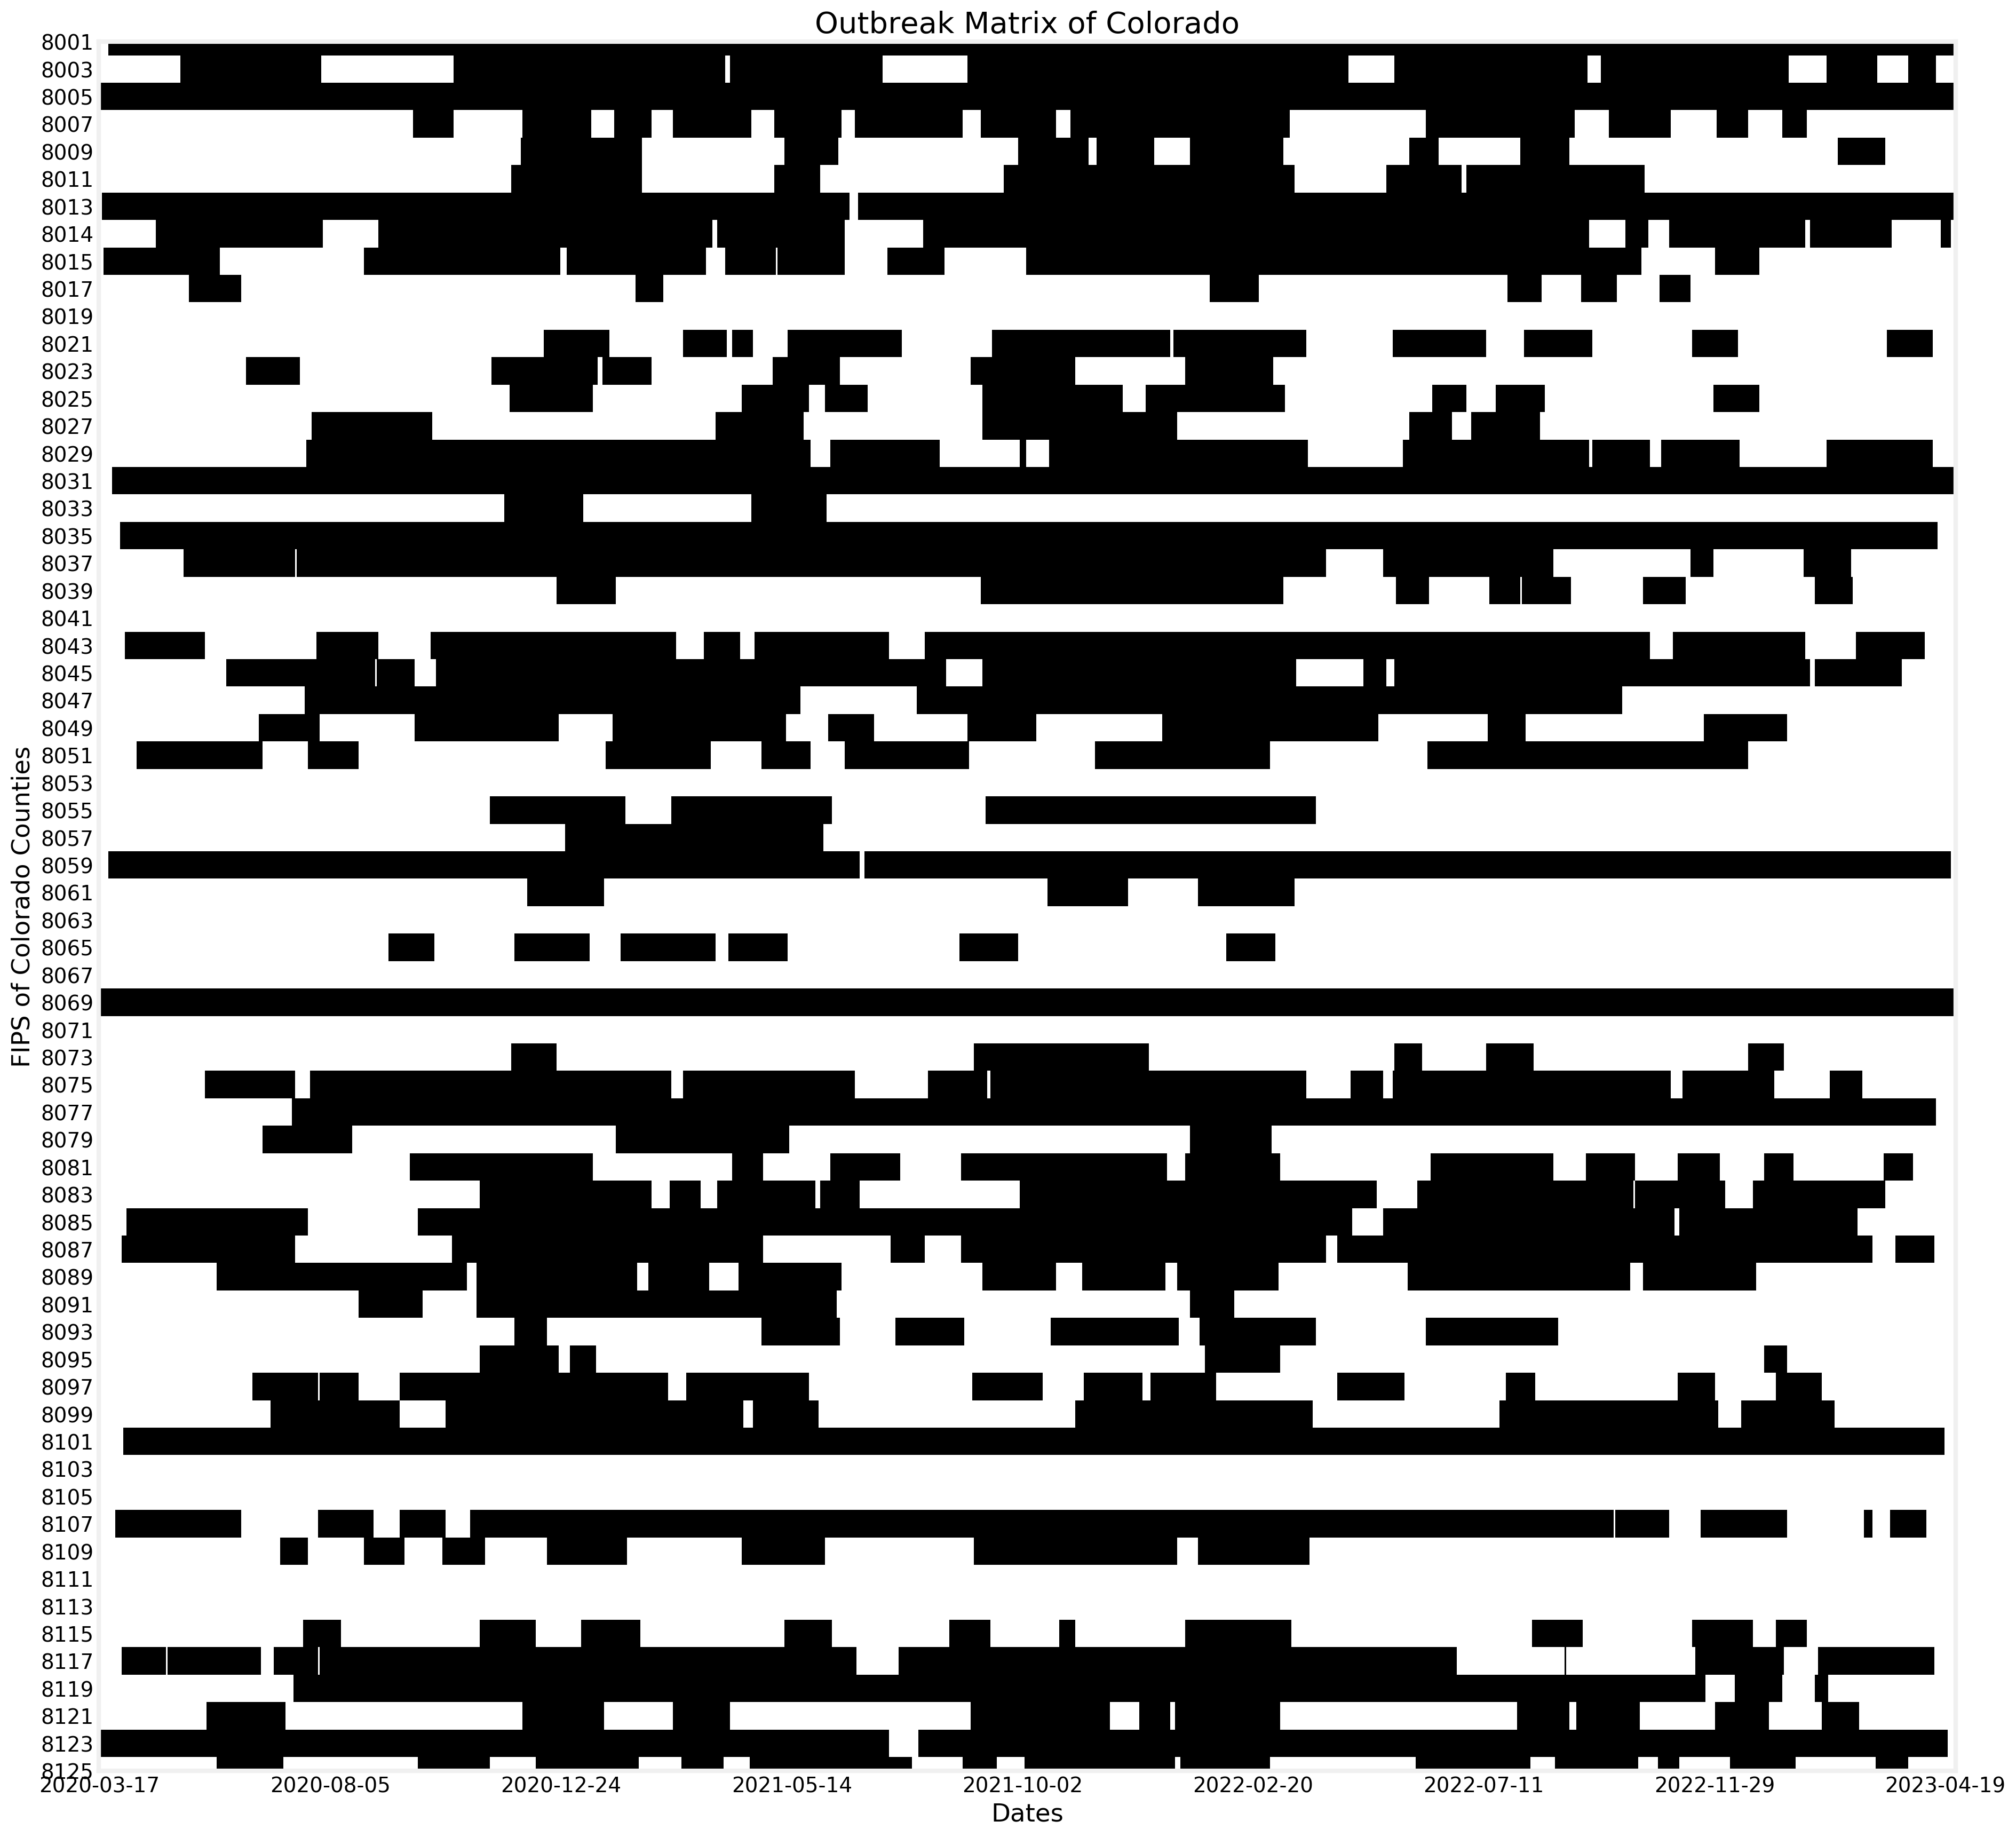

In [15]:
fig, ax =plt.subplots(1,1,figsize=(20,20), dpi= 200, facecolor='w', edgecolor='k')
#plt.rcParams['figure.dpi'] = 200

#plt.xlabel(outbreak_matrix.index)

x_len = outbreak_matrix.shape[1]

x_lims = [(x_len-1)//8 * i for i in range(9)]
#x_labels = mdates.date2num(outbreak_matrix.index)
x_labels = outbreak_matrix.columns.astype(str)
x_labels = x_labels[x_lims]

y_lims = outbreak_matrix.columns

y_label_list = np.array(outbreak_matrix.index.astype(np.int64))

img = ax.imshow(outbreak_matrix, cmap='Greys', aspect="auto")

ax.set_xticks(x_lims)
ax.set_xticklabels(x_labels)
ax.set_yticks(range(len(y_label_list)))
ax.set_yticklabels(y_label_list)



ax.set_title("Outbreak Matrix of Colorado")
ax.set_ylabel("FIPS of Colorado Counties")
ax.set_xlabel("Dates")
#plt.yticks(ticks=y_label_list ,labels=y_label_list)
#plt.xticks(ticks=x_lims ,labels=x_lims)

#plt.imshow(outbreak_matrix.T, cmap='Greys', aspect="auto")
plt.grid(None)
plt.savefig("../figures/Outbreak_Matrix.png")
plt.show()

### Change points from 0 -> 1 to indicate no outbreak to outbreak

In [21]:
changepoint_matrix = outbreak_matrix.T.diff() 
changepoint_matrix

fips,8001,8003,8005,8007,8009,8011,8013,8014,8015,8017,8019,8021,8023,8025,8027,8029,8031,8033,8035,8037,8039,8041,8043,8045,8047,8049,8051,8053,8055,8057,8059,8061,8063,8065,8067,8069,8071,8073,8075,8077,8079,8081,8083,8085,8087,8089,8091,8093,8095,8097,8099,8101,8103,8105,8107,8109,8111,8113,8115,8117,8119,8121,8123,8125
2020-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-18,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-19,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-03-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-21,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0
2023-04-22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-04-23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-04-24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
changepoint_matrix.to_csv("../data/changepoint_matrix.csv", index=True)

In [24]:
changepoint_matrix.index

DatetimeIndex(['2020-03-17', '2020-03-18', '2020-03-19', '2020-03-20',
               '2020-03-21', '2020-03-22', '2020-03-23', '2020-03-24',
               '2020-03-25', '2020-03-26',
               ...
               '2023-04-16', '2023-04-17', '2023-04-18', '2023-04-19',
               '2023-04-20', '2023-04-21', '2023-04-22', '2023-04-23',
               '2023-04-24', '2023-04-25'],
              dtype='datetime64[ns]', length=1135, freq='D')